In [319]:
!pip install prophet

In [322]:
!pip install mlxtend

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 27.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 33.0 MB/s  0:00:00 35.8 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 30.7 MB/s  0:00:00 37.7 MB/s eta 0:00:01
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.7.2
    Uninstalling scikit-learn-1.7.2:
      Successfully uninstalled scikit-learn-1.7.2
  Attempting uninstall: matplotlib━━━━━━━━━━━━━━━━━━━━ 0/3 [scikit-learn]
    Found existing installation: matplotlib 3.10.6 0/3 [scikit-learn]
    Uninstalling matplotlib-3.10.6:━━━━━━━━━━━━━━━ 0/3 [scikit-learn]
      Successfully uninstalled matplotlib-3.10.6m╺━━━━━━━━━━━━━━━━━━━━━━━━━━ 1/3 [matplotlib]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [mlxtend]━━━━━━━━━━ 2/3 [mlxtend]


In [324]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from datetime import datetime

pd.set_option('display.max_columns', None)

import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from sklearn.decomposition import PCA

from scipy.cluster.hierarchy import dendrogram
from scipy.cluster.hierarchy import linkage
from scipy.cluster.hierarchy import fcluster

from sklearn.ensemble import IsolationForest

from prophet import Prophet

from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import association_rules

In [192]:
df = pd.read_csv("online_retail_II.csv", encoding="ISO-8859-1")

In [193]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/10 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/10 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/10 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/10 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/10 8:26,3.39,17850.0,United Kingdom


In [194]:
df.shape

(541910, 8)

In [195]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541910 entries, 0 to 541909
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Invoice      541910 non-null  object 
 1   StockCode    541910 non-null  object 
 2   Description  540456 non-null  object 
 3   Quantity     541910 non-null  int64  
 4   InvoiceDate  541910 non-null  object 
 5   Price        541910 non-null  float64
 6   Customer ID  406830 non-null  float64
 7   Country      541910 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [196]:
df.describe()

,Quantity,Price,Customer ID
count,541910.000000,541910.000000,406830.000000
mean,9.552234,4.611138,15287.684160
std,218.080957,96.759765,1713.603074
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [197]:
df.isnull().sum()

Invoice             0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
Price               0
Customer ID    135080
Country             0
dtype: int64

In [198]:
print("Duplicates:", df.duplicated().sum())

Duplicates: 5268


In [199]:
df.dtypes

Invoice         object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
Price          float64
Customer ID    float64
Country         object
dtype: object

In [200]:
#invoive date convert to date time format
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [201]:
df.dtypes

Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
Price                 float64
Customer ID           float64
Country                object
dtype: object

In [202]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541910 entries, 0 to 541909
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      541910 non-null  object        
 1   StockCode    541910 non-null  object        
 2   Description  540456 non-null  object        
 3   Quantity     541910 non-null  int64         
 4   InvoiceDate  541910 non-null  datetime64[ns]
 5   Price        541910 non-null  float64       
 6   Customer ID  406830 non-null  float64       
 7   Country      541910 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [203]:
#checking for null values
df.isnull().sum()

Invoice             0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
Price               0
Customer ID    135080
Country             0
dtype: int64

In [204]:
#creating revenue feature (most important business feature
df['Revenue'] = df['Quantity'] * df['Price']

In [205]:
df[['Quantity','Price','Revenue']].head()

,Quantity,Price,Revenue
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


In [206]:
print("Negative Quantity Records:",
      (df['Quantity'] < 0).sum())

Negative Quantity Records: 10624


In [207]:
#For demand forecasting and anomaly detection we want actual purchases.
df = df[df['Quantity'] > 0]
df = df[df['Price'] > 0]

In [208]:
print(df.shape)

(530105, 9)


In [209]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [210]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 530105 entries, 0 to 541909
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      530105 non-null  object        
 1   StockCode    530105 non-null  object        
 2   Description  530105 non-null  object        
 3   Quantity     530105 non-null  int64         
 4   InvoiceDate  530105 non-null  datetime64[ns]
 5   Price        530105 non-null  float64       
 6   Customer ID  397885 non-null  float64       
 7   Country      530105 non-null  object        
 8   Revenue      530105 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(4)
memory usage: 40.4+ MB


In [211]:
df.describe()

,Quantity,InvoiceDate,Price,Customer ID,Revenue
count,530105.000000,530105,530105.000000,397885.000000,530105.000000
mean,10.542019,2011-07-04 20:16:30.926476544,3.907652,15294.416882,20.121867
min,1.000000,2010-12-01 08:26:00,0.001000,12346.000000,0.001000
25%,1.000000,2011-03-28 12:22:00,1.250000,13969.000000,3.750000
50%,3.000000,2011-07-20 12:58:00,2.080000,15159.000000,9.900000
75%,10.000000,2011-10-19 12:39:00,4.130000,16795.000000,17.700000
max,80995.000000,2011-12-09 12:50:00,13541.330000,18287.000000,168469.600000
std,155.523977,NaN,35.915652,1713.144421,270.356488


In [212]:
print(df.shape)
df.head()

(530105, 9)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [213]:
print("Total Revenue:", round(df['Revenue'].sum(),2))
print("Average Revenue per Transaction:", round(df['Revenue'].mean(),2))

Total Revenue: 10666702.54
Average Revenue per Transaction: 20.12


In [214]:
#Top 10 Products by Quantity Sold
#TO CHECK HIGH DEMAND PRODUCTS
top_products = (
    df.groupby('Description')['Quantity']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products

Description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        78033
WORLD WAR 2 GLIDERS ASSTD DESIGNS     55047
JUMBO BAG RED RETROSPOT               48474
WHITE HANGING HEART T-LIGHT HOLDER    37891
POPCORN HOLDER                        36761
ASSORTED COLOUR BIRD ORNAMENT         36461
PACK OF 72 RETROSPOT CAKE CASES       36419
RABBIT NIGHT LIGHT                    30788
MINI PAINT SET VINTAGE                26633
Name: Quantity, dtype: int64

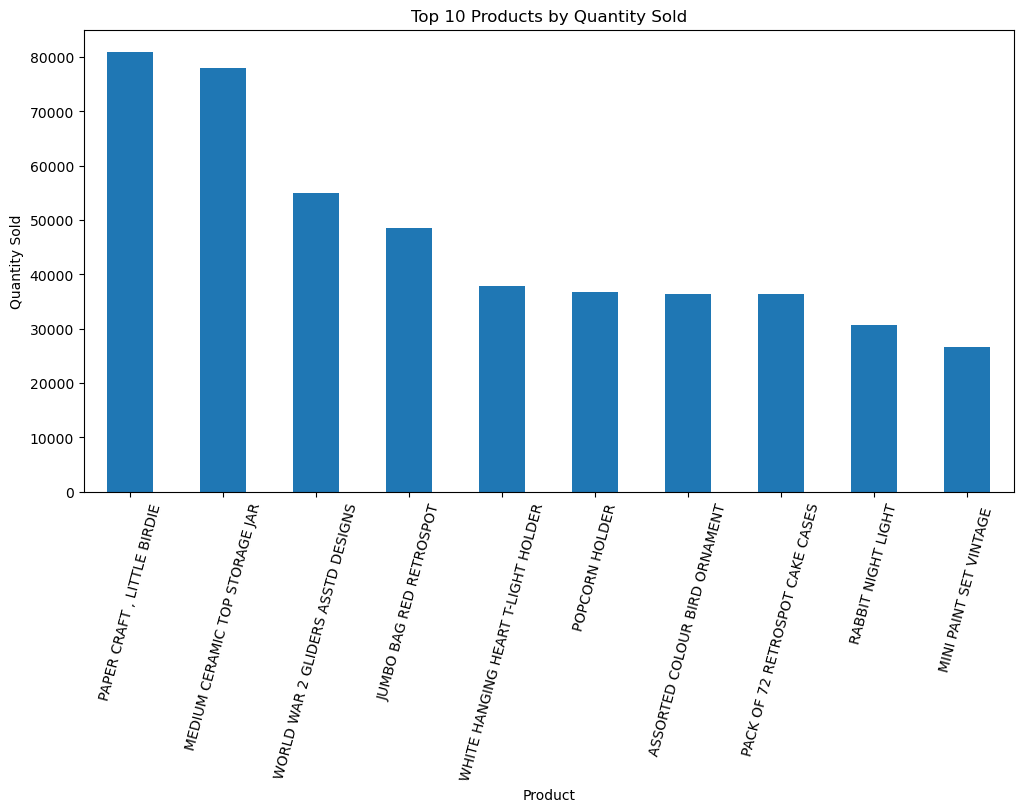

In [215]:
plt.figure(figsize=(12,6))

top_products.plot(kind='bar')

plt.title("Top 10 Products by Quantity Sold")
plt.ylabel("Quantity Sold")
plt.xlabel("Product")

plt.xticks(rotation=75)

plt.show()


In [216]:
#TOP REVENUE GENERATING PRODUCTS
top_revenue_products = (
    df.groupby('Description')['Revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_revenue_products

Description
DOTCOM POSTAGE                        206248.77
REGENCY CAKESTAND 3 TIER              174484.74
PAPER CRAFT , LITTLE BIRDIE           168469.60
WHITE HANGING HEART T-LIGHT HOLDER    106292.77
PARTY BUNTING                          99504.33
JUMBO BAG RED RETROSPOT                94340.05
MEDIUM CERAMIC TOP STORAGE JAR         81700.92
POSTAGE                                78119.88
Manual                                 78112.82
RABBIT NIGHT LIGHT                     66964.99
Name: Revenue, dtype: float64

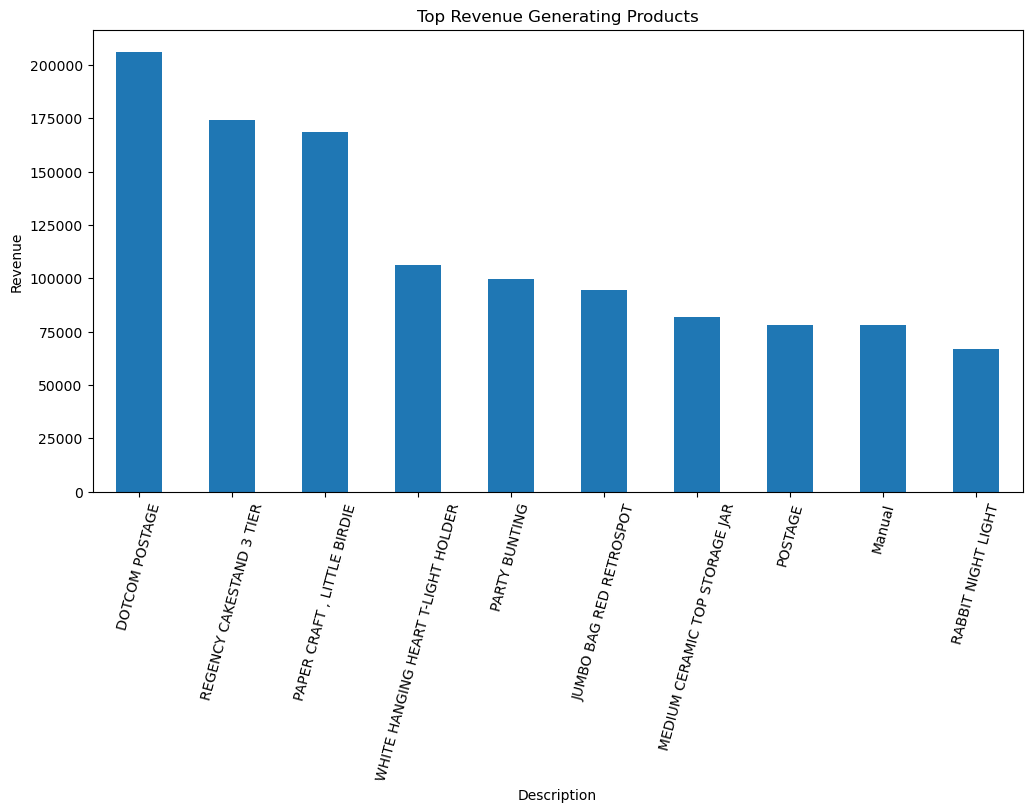

In [217]:
#TOP REVENUE GENERATING PRODUCTS
plt.figure(figsize=(12,6))

top_revenue_products.plot(kind='bar')

plt.title("Top Revenue Generating Products")
plt.ylabel("Revenue")

plt.xticks(rotation=75)

plt.show()

In [218]:
#TOP COUNTRIES BY REVENUE
country_revenue = (
    df.groupby('Country')['Revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

country_revenue

Country
United Kingdom    9025222.084
Netherlands        285446.340
EIRE               283453.960
Germany            228867.140
France             209733.110
Australia          138521.310
Spain               61577.110
Switzerland         57089.900
Belgium             41196.340
Sweden              38378.330
Name: Revenue, dtype: float64

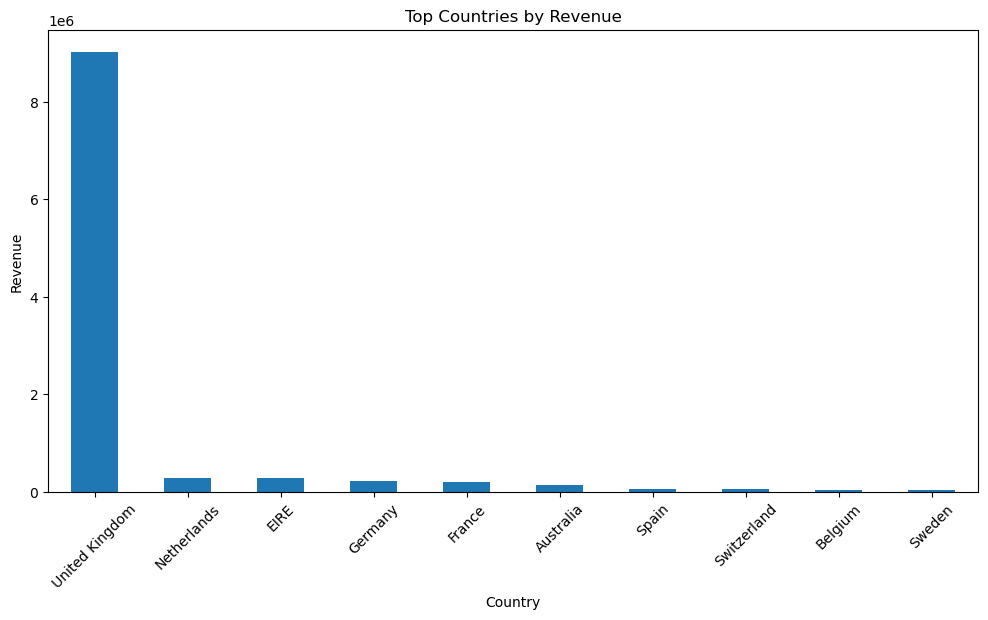

In [219]:
#COUNTRY REVENUE COUNT
plt.figure(figsize=(12,6))

country_revenue.plot(kind='bar')

plt.title("Top Countries by Revenue")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.show()

In [220]:
#MONTHLY REVENUE TREND
#later forecast this
monthly_revenue = (
    df.resample('M', on='InvoiceDate')['Revenue']
    .sum()
)

In [221]:
monthly_revenue.head()

InvoiceDate
2010-12-31    823746.140
2011-01-31    691364.560
2011-02-28    523631.890
2011-03-31    717639.360
2011-04-30    537808.621
Freq: ME, Name: Revenue, dtype: float64

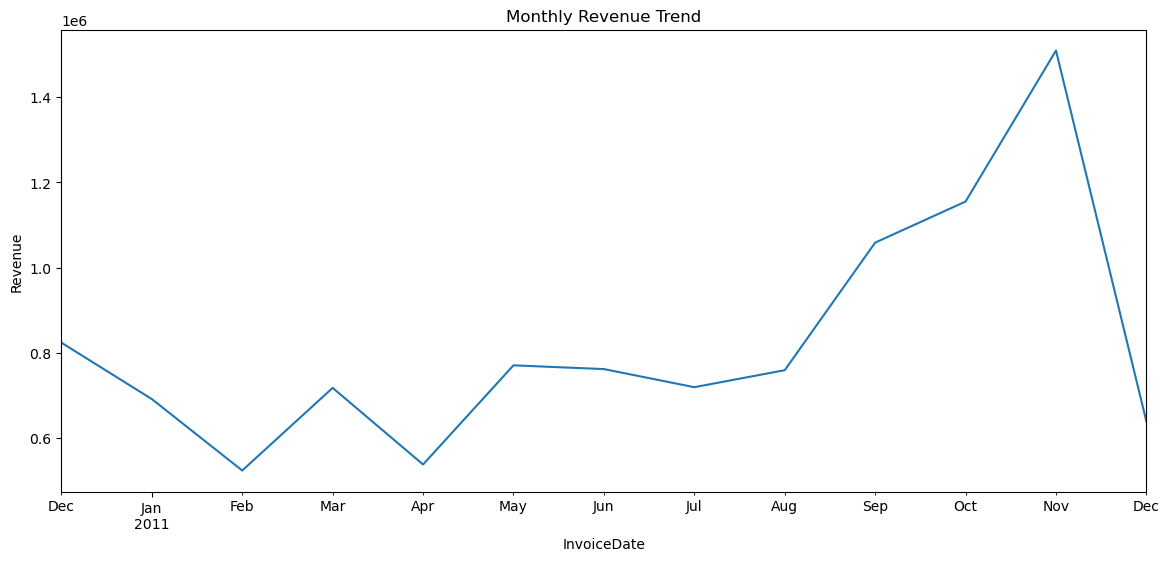

In [222]:
#REVENUE TREND VISUALIZATION
plt.figure(figsize=(14,6))

monthly_revenue.plot()

plt.title("Monthly Revenue Trend")
plt.ylabel("Revenue")

plt.show()

In [223]:
#DAILY DEMAND TREND
daily_demand = (
    df.groupby(df['InvoiceDate'].dt.date)['Quantity']
    .sum()
)

daily_demand.head()

InvoiceDate
2010-12-01    26919
2010-12-02    31329
2010-12-03    16199
2010-12-05    16450
2010-12-06    21795
Name: Quantity, dtype: int64

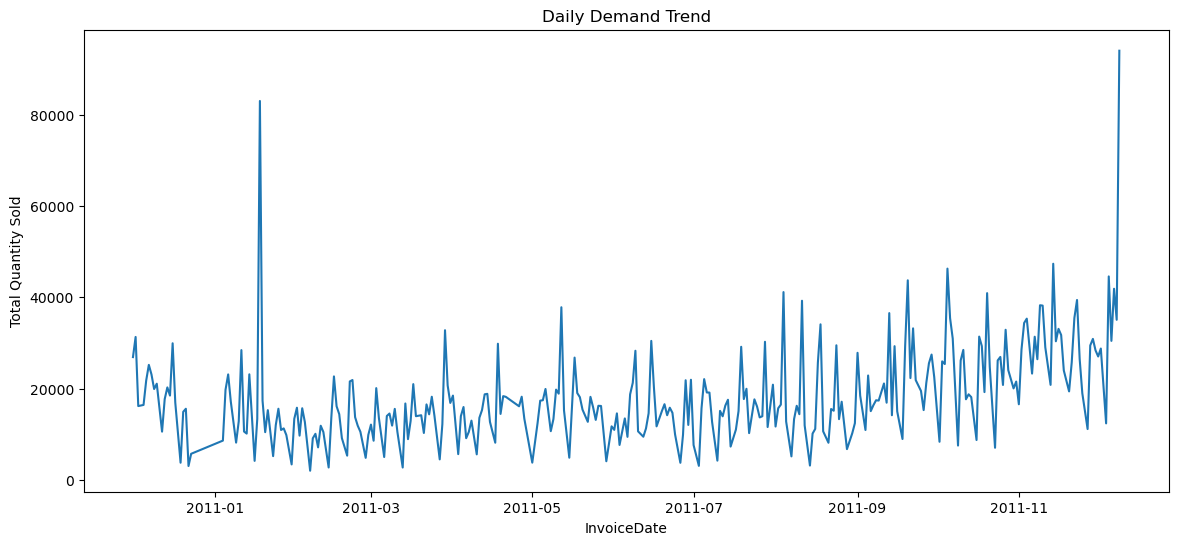

In [224]:
#DAILY DEMAND VISUALIZATION
plt.figure(figsize=(14,6))

daily_demand.plot()

plt.title("Daily Demand Trend")
plt.ylabel("Total Quantity Sold")

plt.show()

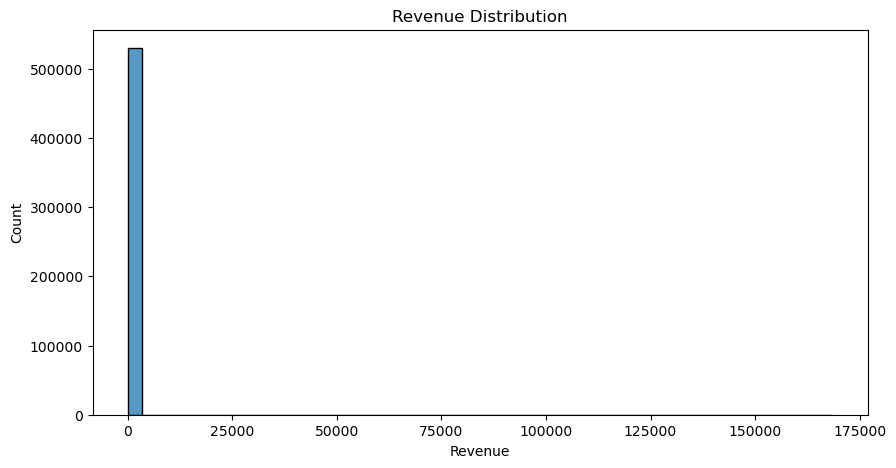

In [225]:
#REVENUE DISTRIBUTION
plt.figure(figsize=(10,5))

sns.histplot(df['Revenue'], bins=50)

plt.title("Revenue Distribution")

plt.show()
#Learning

#Most business datasets are right-skewed.
#Meaning:
#Many small purchases
#Few huge purchases

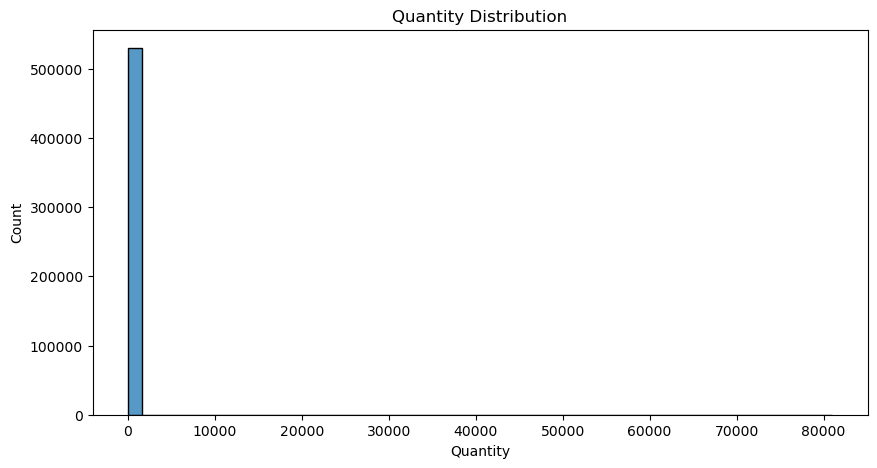

In [226]:
#quantity distributon
plt.figure(figsize=(10,5))

sns.histplot(df['Quantity'], bins=50)

plt.title("Quantity Distribution")

plt.show()

In [227]:
#correlation analysis
corr = df[['Quantity','Price','Revenue']].corr()

corr

,Quantity,Price,Revenue
Quantity,1.000000,-0.003773,0.907338
Price,-0.003773,1.000000,0.137404
Revenue,0.907338,0.137404,1.000000


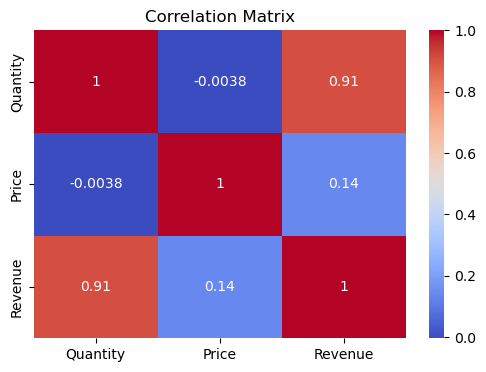

In [228]:
#corelation heat map
plt.figure(figsize=(6,4))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Matrix")

plt.show()

In [229]:
#top customers
#Customer demand drives supply chains.
top_customers = (
    df.groupby('Customer ID')['Revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_customers

Customer ID
14646.0    280206.02
18102.0    259657.30
17450.0    194550.79
16446.0    168472.50
14911.0    143825.06
12415.0    124914.53
14156.0    117379.63
17511.0     91062.38
16029.0     81024.84
12346.0     77183.60
Name: Revenue, dtype: float64

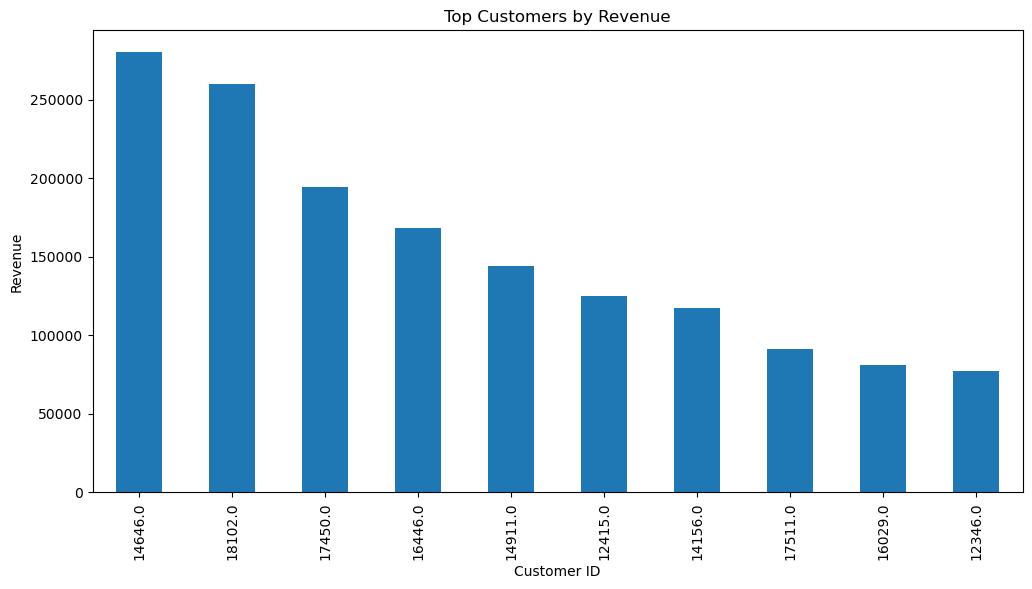

In [230]:
#top customers plot
plt.figure(figsize=(12,6))

top_customers.plot(kind='bar')

plt.title("Top Customers by Revenue")
plt.ylabel("Revenue")

plt.show()

In [231]:
#extracting DATE Features
#Dates contain valuable patterns.
df['Year'] = df['InvoiceDate'].dt.year
df['Month'] = df['InvoiceDate'].dt.month
df['Day'] = df['InvoiceDate'].dt.day
df['Weekday'] = df['InvoiceDate'].dt.day_name()

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,Year,Month,Day,Weekday
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010,12,1,Wednesday
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,1,Wednesday
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010,12,1,Wednesday
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,1,Wednesday
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,1,Wednesday


In [232]:
#Product Purchase Frequency
#Measures how often a product is purchased.
product_frequency = (
    df.groupby('Description')['Invoice']
    .count()
    .reset_index()
)

product_frequency.columns = [
    'Description',
    'Purchase_Frequency'
]

product_frequency.head()

,Description,Purchase_Frequency
0,4 PURPLE FLOCK DINNER CANDLES,41
1,50'S CHRISTMAS GIFT BAG LARGE,129
2,DOLLY GIRL BEAKER,179
3,I LOVE LONDON MINI BACKPACK,88
4,I LOVE LONDON MINI RUCKSACK,1


In [233]:
#PRODUCT LEVEL FEATURES
product_features = df.groupby('Description').agg({
    'Quantity':'sum',
    'Revenue':'sum',
    'Invoice':'count'
}).reset_index()

product_features.columns = [
    'Description',
    'Total_Quantity',
    'Total_Revenue',
    'Purchase_Frequency'
]

In [234]:
#CHECKING PRODUCT FEATURE DATASET
print(product_features.shape)

product_features.head()

#THIS DATA WIL BE USED FOR CLUSTERING

(4026, 4)


,Description,Total_Quantity,Total_Revenue,Purchase_Frequency
0,4 PURPLE FLOCK DINNER CANDLES,144,290.80,41
1,50'S CHRISTMAS GIFT BAG LARGE,1915,2343.63,129
2,DOLLY GIRL BEAKER,2455,2891.25,179
3,I LOVE LONDON MINI BACKPACK,389,1628.17,88
4,I LOVE LONDON MINI RUCKSACK,1,4.15,1


In [235]:
#PRODUCT POPULARITY SCORE
product_features['Popularity_Score'] = (
    product_features['Total_Quantity'] *
    product_features['Purchase_Frequency']
)

In [236]:
product_features.head()

,Description,Total_Quantity,Total_Revenue,Purchase_Frequency,Popularity_Score
0,4 PURPLE FLOCK DINNER CANDLES,144,290.80,41,5904
1,50'S CHRISTMAS GIFT BAG LARGE,1915,2343.63,129,247035
2,DOLLY GIRL BEAKER,2455,2891.25,179,439445
3,I LOVE LONDON MINI BACKPACK,389,1628.17,88,34232
4,I LOVE LONDON MINI RUCKSACK,1,4.15,1,1


In [237]:
#Top Popular Products
product_features.sort_values(
    'Popularity_Score',
    ascending=False
).head(10)

,Description,Total_Quantity,Total_Revenue,Purchase_Frequency,Popularity_Score
1816,JUMBO BAG RED RETROSPOT,48474,94340.05,2112,102377088
3844,WHITE HANGING HEART T-LIGHT HOLDER,37891,106292.77,2323,88020793
227,ASSORTED COLOUR BIRD ORNAMENT,36461,59094.93,1489,54290429
2337,PACK OF 72 RETROSPOT CAKE CASES,36419,21259.10,1370,49894030
2741,RABBIT NIGHT LIGHT,30788,66964.99,1036,31896368
2413,PARTY BUNTING,18295,99504.33,1706,31211270
2003,LUNCH BAG RED RETROSPOT,19353,35752.01,1594,30848682
2681,POPCORN HOLDER,36761,34298.87,829,30474869
3934,WORLD WAR 2 GLIDERS ASSTD DESIGNS,55047,13841.85,537,29560239
2853,REGENCY CAKESTAND 3 TIER,13879,174484.74,2017,27993943


In [238]:
#CUSTOMER LEVEL FEATURES
customer_features = df.groupby('Customer ID').agg({
    'Revenue':'sum',
    'Invoice':'count',
    'Quantity':'sum'
}).reset_index()

customer_features.columns = [
    'Customer_ID',
    'Total_Spending',
    'Purchase_Count',
    'Total_Quantity'
]

customer_features.head()

,Customer_ID,Total_Spending,Purchase_Count,Total_Quantity
0,12346.0,77183.60,1,74215
1,12347.0,4310.00,182,2458
2,12348.0,1797.24,31,2341
3,12349.0,1757.55,73,631
4,12350.0,334.40,17,197


In [239]:
#CUSTOMER DEMAND SCORE
customer_features['Demand_Score'] = (
    customer_features['Total_Spending'] *
    customer_features['Purchase_Count']
)
customer_features.head()

,Customer_ID,Total_Spending,Purchase_Count,Total_Quantity,Demand_Score
0,12346.0,77183.60,1,74215,77183.60
1,12347.0,4310.00,182,2458,784420.00
2,12348.0,1797.24,31,2341,55714.44
3,12349.0,1757.55,73,631,128301.15
4,12350.0,334.40,17,197,5684.80


In [240]:
# DAILY DEMAND DATASET
daily_demand = (
    df.groupby(df['InvoiceDate'].dt.date)
    ['Quantity']
    .sum()
    .reset_index()
)

daily_demand.columns = [
    'Date',
    'Daily_Demand'
]

daily_demand.head(10)


,Date,Daily_Demand
0,2010-12-01,26919
1,2010-12-02,31329
2,2010-12-03,16199
3,2010-12-05,16450
4,2010-12-06,21795
5,2010-12-07,25220
6,2010-12-08,23117
7,2010-12-09,19930
8,2010-12-10,21097
9,2010-12-12,10603


In [241]:
#DAILY REVENUE DATASET
daily_revenue = (
    df.groupby(df['InvoiceDate'].dt.date)
    ['Revenue']
    .sum()
    .reset_index()
)

daily_revenue.columns = [
    'Date',
    'Daily_Revenue'
]

daily_revenue.head(10)

,Date,Daily_Revenue
0,2010-12-01,58960.79
1,2010-12-02,47748.38
2,2010-12-03,46943.71
3,2010-12-05,31774.95
4,2010-12-06,54830.46
5,2010-12-07,99618.20
6,2010-12-08,45389.98
7,2010-12-09,53586.18
8,2010-12-10,59182.92
9,2010-12-12,17329.07


In [242]:
print(product_features.shape)
print(customer_features.shape)
print(daily_demand.shape)
print(daily_revenue.shape)

(4026, 5)
(4338, 5)
(305, 2)
(305, 2)


### selecting features for clustering

In [243]:
clustering_data = product_features[
    [
        'Total_Quantity',
        'Total_Revenue',
        'Purchase_Frequency',
        'Popularity_Score'
    ]
]

clustering_data.head()

,Total_Quantity,Total_Revenue,Purchase_Frequency,Popularity_Score
0,144,290.80,41,5904
1,1915,2343.63,129,247035
2,2455,2891.25,179,439445
3,389,1628.17,88,34232
4,1,4.15,1,1


In [244]:
#standardizing
#K-Means is distance-based. Features with larger numerical ranges can dominate the clustering process.
#Standardization ensures all features contribute equally.
scaler = StandardScaler()
scaled_data = scaler.fit_transform(clustering_data)

In [245]:
scaled_data[:5]

array([[-0.35904305, -0.30183398, -0.46793007, -0.19376251],
       [ 0.15207315, -0.03913593, -0.01378131, -0.11933373],
       [ 0.30791885,  0.0309423 ,  0.24425775, -0.05994343],
       [-0.28833527, -0.13069244, -0.22537335, -0.18501864],
       [-0.4003133 , -0.33851621, -0.67436132, -0.19558456]])

ELBOW METHOD

In [246]:
inertia = []

for k in range(1,11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(scaled_data)

    inertia.append(kmeans.inertia_)

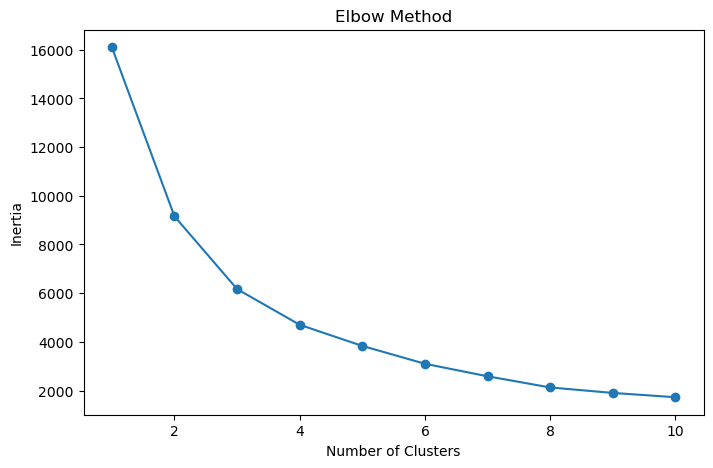

In [247]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    inertia,
    marker='o'
)

plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')

plt.title('Elbow Method')

plt.show()

In [248]:
#k=3 seems optimal

#verifying with silhoette score aswell
for k in range(2, 8):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(scaled_data)

    score = silhouette_score(
        scaled_data,
        labels
    )

    print(f"K={k}  Silhouette Score={score:.4f}")

K=2  Silhouette Score=0.8604
K=3  Silhouette Score=0.7697
K=4  Silhouette Score=0.6764
K=5  Silhouette Score=0.6782
K=6  Silhouette Score=0.6759
K=7  Silhouette Score=0.6625


In [249]:
#TRAINING FINAL MODEL K-MEANS

In [250]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

product_features['Cluster'] = kmeans.fit_predict(
    scaled_data
)

In [251]:
product_features['Cluster'].value_counts()

Cluster
2    3681
0     329
1      16
Name: count, dtype: int64

In [252]:
cluster_summary = product_features.groupby('Cluster')[
    [
        'Total_Quantity',
        'Total_Revenue',
        'Purchase_Frequency',
        'Popularity_Score'
    ]
].mean()

cluster_summary

,Total_Quantity,Total_Revenue,Purchase_Frequency,Popularity_Score
Cluster,,,,
0,7132.990881,14047.219726,587.103343,4.537105e+06
1,34889.125000,81426.839375,1215.937500,3.574383e+07
2,728.985873,1288.328667,86.251834,1.321527e+05


CLUSTER 1
Quantity = Highest

Revenue = Highest

Frequency = Highest

Popularity = Highest

Business Meaning
 Fast Moving Products

CLUSTER 0 

Middle values everywhere

Business Meaning

Medium Moving Products

CLUSTER 2

Very low quantity


Very low revenue

Very low frequency

Business Meaning
 Slow Moving Products

In [253]:
#ADDING LABELS
cluster_mapping = {
    1: 'Fast Moving',
    0: 'Medium Moving',
    2: 'Slow Moving'
}

product_features['Segment'] = (
    product_features['Cluster']
    .map(cluster_mapping)
)

In [254]:
product_features[
    ['Description','Cluster','Segment']
].head()

,Description,Cluster,Segment
0,4 PURPLE FLOCK DINNER CANDLES,2,Slow Moving
1,50'S CHRISTMAS GIFT BAG LARGE,2,Slow Moving
2,DOLLY GIRL BEAKER,2,Slow Moving
3,I LOVE LONDON MINI BACKPACK,2,Slow Moving
4,I LOVE LONDON MINI RUCKSACK,2,Slow Moving


## PCA

In [255]:
pca = PCA(n_components=2)

pca_features = pca.fit_transform(
    scaled_data
)

In [256]:
print(pca_features.shape)
# MEANS 4026 products
#2 principal components

(4026, 2)


In [257]:
pca_df = pd.DataFrame(
    pca_features,
    columns=['PC1','PC2']
)

pca_df['Cluster'] = product_features['Cluster']
pca_df['Segment'] = product_features['Segment']

pca_df.head(1000)

,PC1,PC2,Cluster,Segment
0,-0.661792,-0.076912,2,Slow Moving
1,-0.009125,-0.022438,2,Slow Moving
2,0.263874,-0.011158,2,Slow Moving
3,-0.416349,0.064310,2,Slow Moving
4,-0.805519,-0.125898,2,Slow Moving
...,...,...,...,...
995,0.952808,-0.733775,2,Slow Moving
996,0.172326,0.193065,2,Slow Moving
997,-0.356484,-0.006229,2,Slow Moving
998,0.237010,0.167066,2,Slow Moving


In [258]:
print( pca.explained_variance_ratio_ )



[0.76036796 0.10298029]


PC1 explains 76%
PC2 explains 10%

Total = 86%

86% of information retained

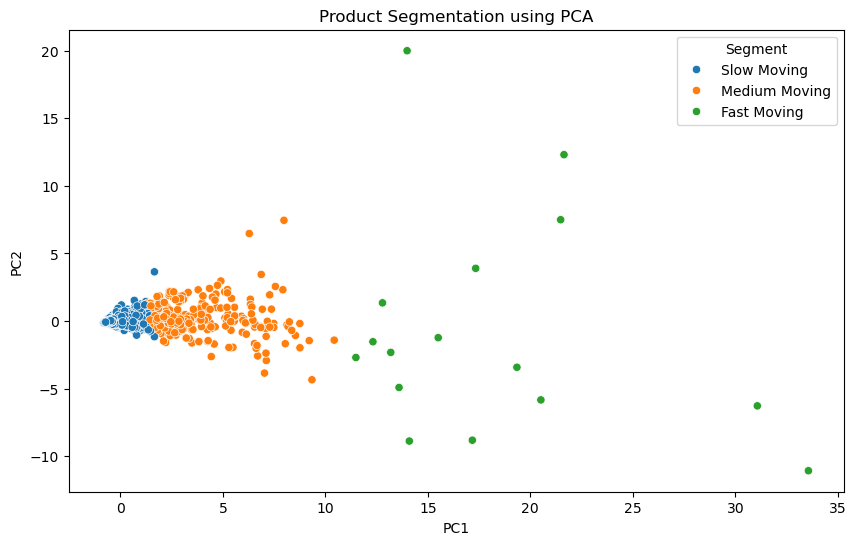

In [259]:
#PCA Cluster Visualization
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=pca_df,
    x='PC1',
    y='PC2',
    hue='Segment'
)

plt.title(
    'Product Segmentation using PCA'
)

plt.show()

## Hierarchical Clustering

In [262]:
#USING WARD LINKAGE

linked = linkage(
    scaled_data,
    method='ward'
)

WHAT HAPPEND 

4026 products
=
4026 clusters

Ward starts merging the most similar clusters.

Eventually:

    4026
↓
4025
↓
4024
↓
...
↓
1 cluster
This entire merging history is stored inside: linked

In [263]:
linked.shape
#N - 1 merges

(4025, 4)

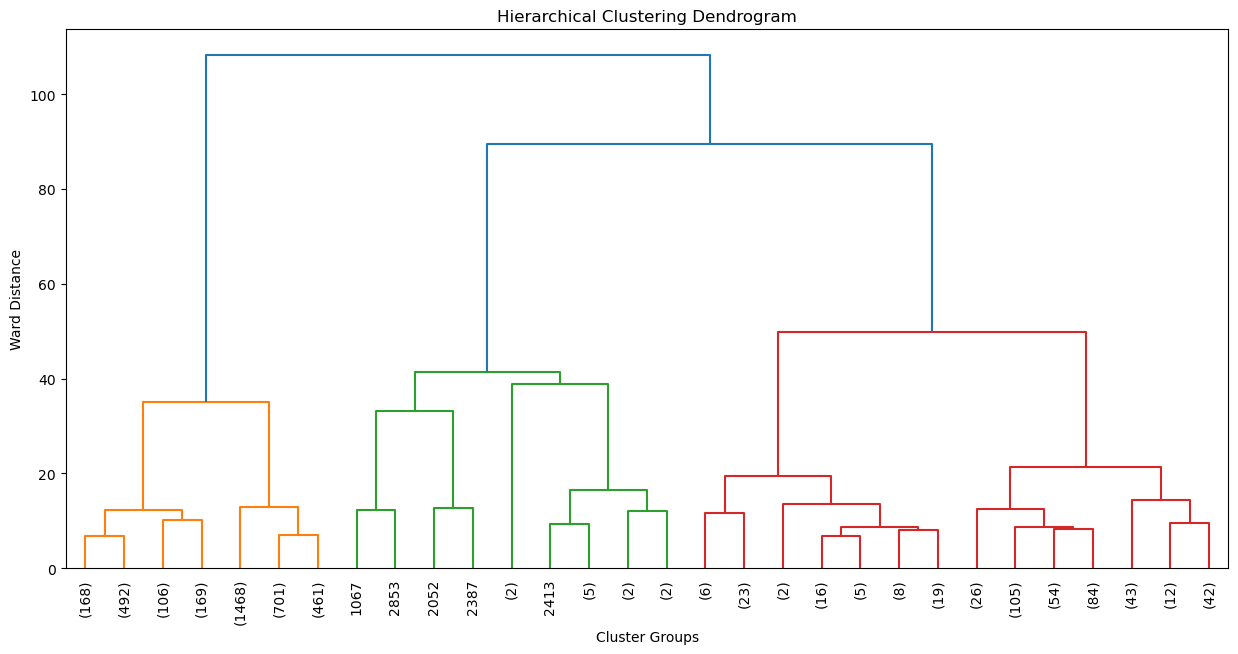

In [264]:
#PLOTING DENDOGRAM
plt.figure(figsize=(15,7))

dendrogram(
    linked,
    truncate_mode='lastp',
    p=30,
    leaf_rotation=90,
    leaf_font_size=10
)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Cluster Groups")
plt.ylabel("Ward Distance")

plt.show()

In [267]:
#CRETING FINAL CLUSTERS
product_features['HC_Cluster'] = fcluster(
    linked,
    t=3,
    criterion='maxclust'
)

In [268]:
product_features['HC_Cluster'].value_counts()

HC_Cluster
1    3565
3     445
2      16
Name: count, dtype: int64

In [269]:
hc_summary = product_features.groupby(
    'HC_Cluster'
)[
    [
        'Total_Quantity',
        'Total_Revenue',
        'Purchase_Frequency',
        'Popularity_Score'
    ]
].mean()

hc_summary

,Total_Quantity,Total_Revenue,Purchase_Frequency,Popularity_Score
HC_Cluster,,,,
1,638.664516,1124.730683,78.166620,1.010367e+05
2,34889.125000,81426.839375,1215.937500,3.574383e+07
3,6187.217978,12031.928607,521.316854,3.638126e+06


In [270]:
pd.crosstab(
    product_features['Cluster'],
    product_features['HC_Cluster']
)

HC_Cluster,1,2,3
Cluster,,,
0,0,0,329
1,0,16,0
2,3565,0,116


In [ ]:
#PERFECT MATCH WITH K MEANS CUSSTERING THEREFORE VALIDATION AND CONFIDENSE

## DYNAMIC ANOMALY DETECTION

In [271]:
daily_demand.head()

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


,Date,Daily_Demand
0,2010-12-01,26919
1,2010-12-02,31329
2,2010-12-03,16199
3,2010-12-05,16450
4,2010-12-06,21795


In [272]:
daily_demand.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 305 entries, 0 to 304
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Date          305 non-null    object
 1   Daily_Demand  305 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 4.9+ KB


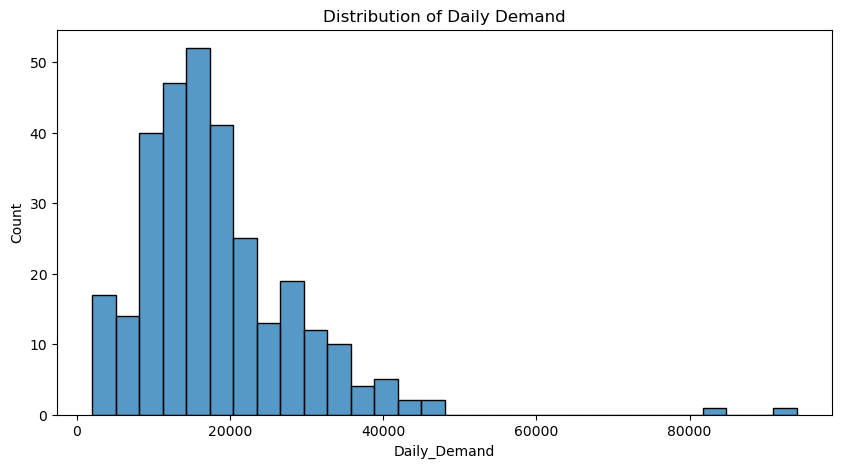

In [273]:
#Distribution of Daily Demand
plt.figure(figsize=(10,5))

sns.histplot(
    daily_demand['Daily_Demand'],
    bins=30
)

plt.title('Distribution of Daily Demand')

plt.show()

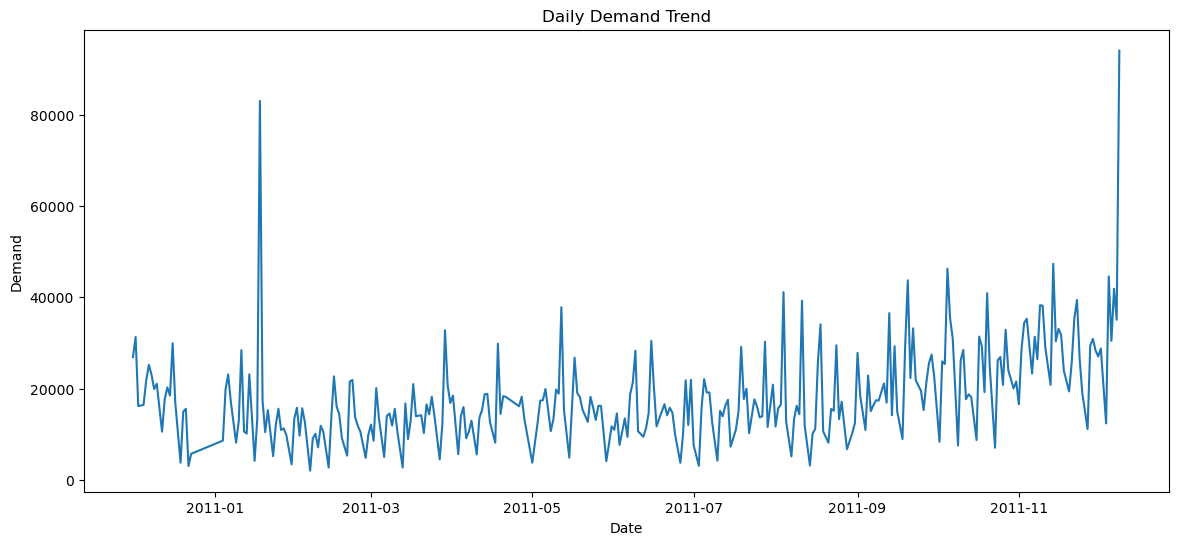

In [275]:
#DEMAND TREND
plt.figure(figsize=(14,6))

plt.plot(
    daily_demand['Date'],
    daily_demand['Daily_Demand']
)

plt.title('Daily Demand Trend')

plt.xlabel('Date')
plt.ylabel('Demand')

plt.show()

Before anomaly detection:

You should visually inspect.

Sometimes anomalies are already visible.

In [279]:
iso_forest = IsolationForest(
    contamination=0.05,
    random_state=42
)
#ASUMING 5% ANOMALIES
# 305 × 0.05 ≈ 15 days

In [280]:
daily_demand['Anomaly'] = (
    iso_forest.fit_predict(
        daily_demand[['Daily_Demand']]
    )
)

In [284]:
daily_demand.head(1000)
# 1= NORMAL
# -1= ANOMALY

,Date,Daily_Demand,Anomaly
0,2010-12-01,26919,1
1,2010-12-02,31329,1
2,2010-12-03,16199,1
3,2010-12-05,16450,1
4,2010-12-06,21795,1
...,...,...,...
300,2011-12-05,44578,-1
301,2011-12-06,30468,1
302,2011-12-07,41880,-1
303,2011-12-08,35085,1


In [285]:
daily_demand['Anomaly'].value_counts()

Anomaly
 1    289
-1     16
Name: count, dtype: int64

In [287]:
#Extracting  Anomalies

anomalies = daily_demand[
    daily_demand['Anomaly'] == -1
]

anomalies.head()

,Date,Daily_Demand,Anomaly
32,2011-01-18,82978,-1
48,2011-02-06,2048,-1
54,2011-02-13,2756,-1
78,2011-03-13,2749,-1
125,2011-05-12,37829,-1


In [288]:
print(anomalies.shape)

(16, 3)


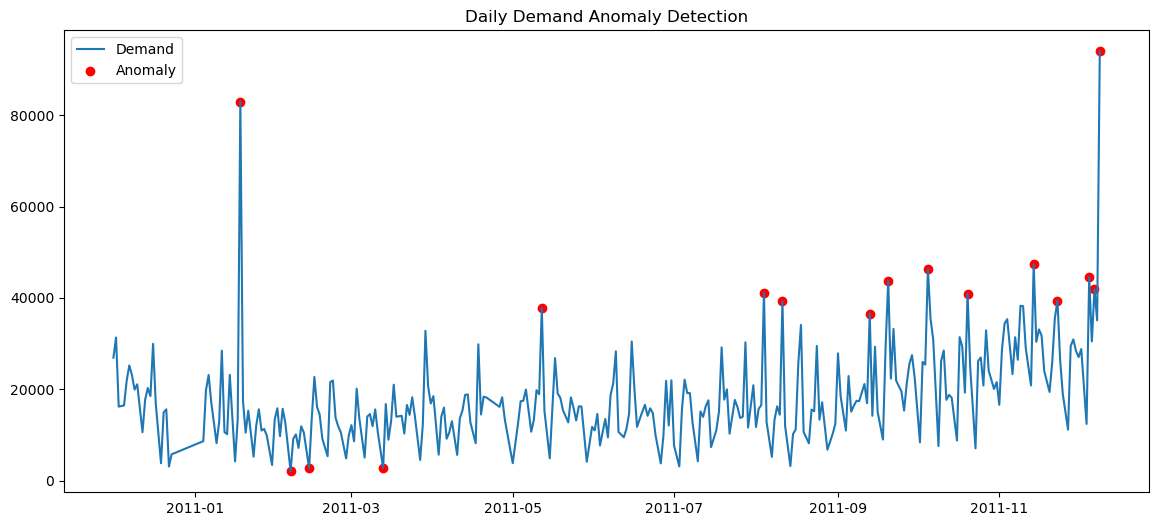

In [290]:
#visualising anomaly
plt.figure(figsize=(14,6))

plt.plot(
    daily_demand['Date'],
    daily_demand['Daily_Demand'],
    label='Demand'
)

plt.scatter(
    anomalies['Date'],
    anomalies['Daily_Demand'],
    color='red',
    label='Anomaly'
)

plt.title(
    'Daily Demand Anomaly Detection'
)

plt.legend()

plt.show()

In [292]:
#top anomaly days
anomalies.sort_values(
    'Daily_Demand',
    ascending=False
).head(10)

,Date,Daily_Demand,Anomaly
304,2011-12-09,93980,-1
32,2011-01-18,82978,-1
282,2011-11-14,47353,-1
248,2011-10-05,46286,-1
300,2011-12-05,44578,-1
235,2011-09-20,43726,-1
302,2011-12-07,41880,-1
196,2011-08-04,41148,-1
261,2011-10-20,40919,-1
290,2011-11-23,39420,-1


Isolation Forest identified unusual demand spikes and drops that may indicate abnormal purchasing behavior, promotional effects, seasonal events, or potential inventory planning risks.

also looking at the data most anomalies ocue in nvember-december

November–December often contains:

* Holiday shopping
* Christmas purchases
* Seasonal demand spikes
* Bulk orders
some of anomalies may actually be Business events rather than error

In [293]:
anomalies.sort_values(
    'Date'
)

,Date,Daily_Demand,Anomaly
32,2011-01-18,82978,-1
48,2011-02-06,2048,-1
54,2011-02-13,2756,-1
78,2011-03-13,2749,-1
125,2011-05-12,37829,-1
196,2011-08-04,41148,-1
202,2011-08-11,39254,-1
229,2011-09-13,36548,-1
235,2011-09-20,43726,-1
248,2011-10-05,46286,-1


one business insight most of them are clustered around late 2011.

## DEMAND FORECASTING

In [299]:
#PREPARING PROPHET DATASET
daily_demand.columns

Index(['Date', 'Daily_Demand', 'Anomaly'], dtype='object')

In [301]:
prophet_df = daily_demand.rename(
    columns={
        'Date':'ds',
        'Daily_Demand':'y'
    }
)[['ds','y']]
#The anomaly label is not part of the forecasting target
#We’re forecasting Future Demand

In [302]:
prophet_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 305 entries, 0 to 304
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   ds      305 non-null    object
 1   y       305 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 4.9+ KB


Prophet requires: ds -> datetime
AND
ds -> object

In [306]:
#CONVERTING TO DAYE TIME
prophet_df['ds'] = pd.to_datetime(prophet_df['ds'])

In [307]:
prophet_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 305 entries, 0 to 304
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   ds      305 non-null    datetime64[ns]
 1   y       305 non-null    int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 4.9 KB


In [308]:
model = Prophet()

model.fit(prophet_df)

05:06:15 - cmdstanpy - INFO - Chain [1] start processing
05:06:16 - cmdstanpy - INFO - Chain [1] done processing


In [309]:
future = model.make_future_dataframe(periods=30)

forecast = model.predict(future)

In [310]:
forecast[['ds','yhat']].tail()

,ds,yhat
330,2012-01-04,35628.901150
331,2012-01-05,39137.025120
332,2012-01-06,34011.961560
333,2012-01-07,41232.292536
334,2012-01-08,26068.307192


last 5 forecasted values are:
Date

Predicted Demand

2012-01-04

35,629

2012-01-05

39,137

2012-01-06

34,012

2012-01-07

41,232

2012-01-08

26,068

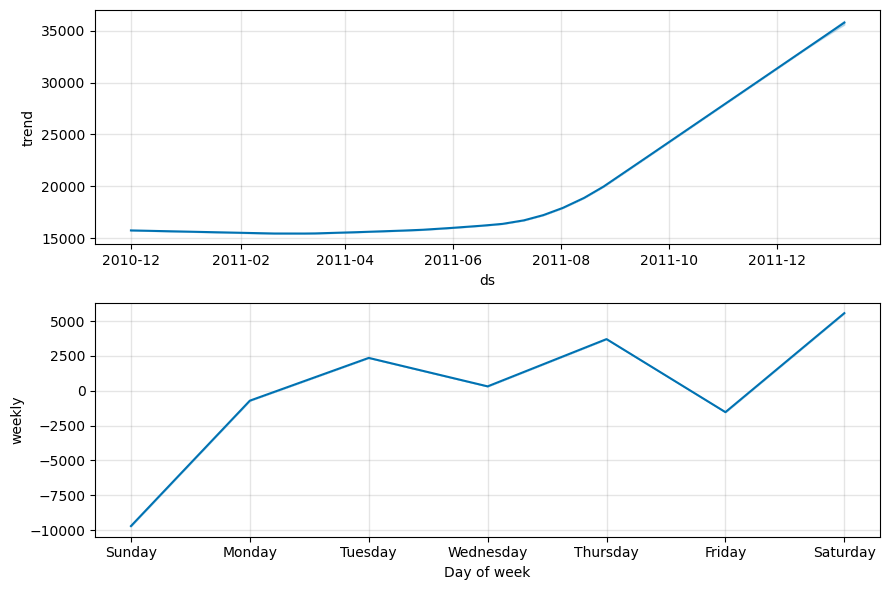

In [311]:
fig2 = model.plot_components(forecast)

The component plot reveals:

* Overall trend
* Weekly seasonality
* Any recurring patterns


Important Observation

2012-01-07 → 41,232
2012-01-08 → 26,068
large drop.

 happens because Prophet has identified a weekday/weekend effect.

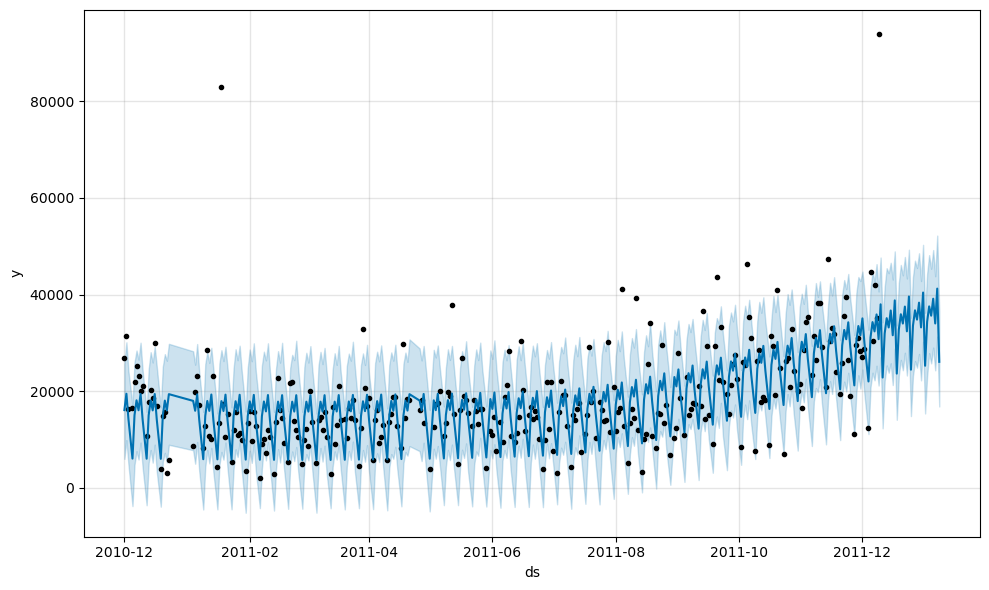

In [312]:
fig1 = model.plot(forecast)

### Prophet

### Forecasting Next 30 days demand

# RECOMMENDATION SYSTEM
## Frequently Bought Together (Market Basket Analysis)

In [ ]:
# recommendation system identifies products that are frequently purchased together, 
# helping businesses optimize inventory placement, product bundling, and demand planning

In [314]:
#CREATING BASKET DATASET
basket = df.groupby(
    ['Invoice', 'Description']
)['Quantity'].sum().unstack().fillna(0)

In [315]:
basket.shape

(19960, 4026)

Convert to Binary

We only care whether a product was purchased.

In [ ]:
basket = basket.applymap(
    lambda x: 1 if x > 0 else 0
)

In [321]:
basket.head()

Description   4 PURPLE FLOCK DINNER CANDLES   50'S CHRISTMAS GIFT BAG LARGE  \
Invoice                                                                       
536365                                    0                               0   
536366                                    0                               0   
536367                                    0                               0   
536368                                    0                               0   
536369                                    0                               0   

Description   DOLLY GIRL BEAKER   I LOVE LONDON MINI BACKPACK  \
Invoice                                                         
536365                        0                             0   
536366                        0                             0   
536367                        0                             0   
536368                        0                             0   
536369                        0                             0   

Description   I LOVE LONDON MINI RUCKSACK   NINE DRAWER OFFICE TIDY  \
Invoice                                                               
536365                                  0                         0   
536366                                  0                         0   
536367                                  0                         0   
536368                                  0                         0   
536369                                  0                         0   

Description   OVAL WALL MIRROR DIAMANTE    RED SPOT GIFT BAG LARGE  \
Invoice                                                              
536365                                 0                         0   
536366                                 0                         0   
536367                                 0                         0   
536368                                 0                         0   
536369                                 0                         0   

Description   SET 2 TEA TOWELS I LOVE LONDON    SPACEBOY BABY GIFT SET  \
Invoice                                                                  
536365                                      0                        0   
536366                                      0                        0   
536367                                      0                        0   
536368                                      0                        0   
536369                                      0                        0   

Description   TOADSTOOL BEDSIDE LIGHT    TRELLIS COAT RACK  \
Invoice                                                      
536365                               0                   0   
536366                               0                   0   
536367                               0                   0   
536368                               0                   0   
536369                               0                   0   

Description  *Boombox Ipod Classic  *USB Office Mirror Ball  \
Invoice                                                       
536365                           0                        0   
536366                           0                        0   
536367                           0                        0   
536368                           0                        0   
536369                           0                        0   

Description  10 COLOUR SPACEBOY PEN  12 COLOURED PARTY BALLOONS  \
Invoice                                                           
536365                            0                           0   
536366                            0                           0   
536367                            0                           0   
536368                            0                           0   
536369                            0                           0   

Description  12 DAISY PEGS IN WOOD BOX  12 EGG HOUSE PAINTED WOOD  \
Invoice                                                           

In [327]:
#Find Frequent Itemsets
frequent_items = apriori(
    basket,
    min_support=0.02,
    use_colnames=True
)

/opt/anaconda3/lib/python3.13/site-packages/mlxtend/frequent_patterns/fpcommon.py:175: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


In [328]:
frequent_items.sort_values(
    'support',
    ascending=False
).head()

,support,itemsets
276,0.113026,(WHITE HANGING HEART T-LIGHT HOLDER)
103,0.104659,(JUMBO BAG RED RETROSPOT)
199,0.099599,(REGENCY CAKESTAND 3 TIER)
158,0.084419,(PARTY BUNTING)
128,0.078357,(LUNCH BAG RED RETROSPOT)


In [ ]:
Support

How often the combination occurs.

Confidence
If customer buys A,
how often do they buy B?

Lift
Lift > 1

Products are positively associated.

Higher lift = stronger recommendation.

In [329]:
#Generate Association Rules
rules = association_rules(
    frequent_items,
    metric='lift',
    min_threshold=1
)

In [330]:
# Best Recommendations
rules.sort_values(
    'lift',
    ascending=False
).head(20)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
160,"(ROSES REGENCY TEACUP AND SAUCER , GREEN REGEN...",(PINK REGENCY TEACUP AND SAUCER),0.038427,0.038327,0.027104,0.705346,18.403524,1.0,0.025631,3.263732,0.983454,0.545913,0.693602,0.706268
161,(PINK REGENCY TEACUP AND SAUCER),"(ROSES REGENCY TEACUP AND SAUCER , GREEN REGEN...",0.038327,0.038427,0.027104,0.707190,18.403524,1.0,0.025631,3.283944,0.983351,0.545913,0.695488,0.706268
158,"(PINK REGENCY TEACUP AND SAUCER, ROSES REGENCY...",(GREEN REGENCY TEACUP AND SAUCER),0.029960,0.050752,0.027104,0.904682,17.825724,1.0,0.025584,9.958782,0.973054,0.505607,0.899586,0.719370
163,(GREEN REGENCY TEACUP AND SAUCER),"(PINK REGENCY TEACUP AND SAUCER, ROSES REGENCY...",0.050752,0.029960,0.027104,0.534057,17.825724,1.0,0.025584,2.081887,0.994367,0.505607,0.519667,0.719370
24,(PINK REGENCY TEACUP AND SAUCER),(GREEN REGENCY TEACUP AND SAUCER),0.038327,0.050752,0.031663,0.826144,16.278213,1.0,0.029718,5.459963,0.975974,0.551483,0.816849,0.725017
25,(GREEN REGENCY TEACUP AND SAUCER),(PINK REGENCY TEACUP AND SAUCER),0.050752,0.038327,0.031663,0.623889,16.278213,1.0,0.029718,2.556890,0.988749,0.551483,0.608900,0.725017
159,"(PINK REGENCY TEACUP AND SAUCER, GREEN REGENCY...",(ROSES REGENCY TEACUP AND SAUCER ),0.031663,0.053357,0.027104,0.856013,16.043204,1.0,0.025415,6.574490,0.968329,0.467993,0.847897,0.681997
162,(ROSES REGENCY TEACUP AND SAUCER ),"(PINK REGENCY TEACUP AND SAUCER, GREEN REGENCY...",0.053357,0.031663,0.027104,0.507981,16.043204,1.0,0.025415,1.968089,0.990519,0.467993,0.491893,0.681997
22,(GARDENERS KNEELING PAD CUP OF TEA ),(GARDENERS KNEELING PAD KEEP CALM ),0.037976,0.045741,0.027355,0.720317,15.747557,1.0,0.025618,3.411924,0.973466,0.485333,0.706910,0.659173
23,(GARDENERS KNEELING PAD KEEP CALM ),(GARDENERS KNEELING PAD CUP OF TEA ),0.045741,0.037976,0.027355,0.598028,15.747557,1.0,0.025618,2.393264,0.981388,0.485333,0.582161,0.659173


In [331]:
# Create Top Recommendations Table
recommendations = rules[
    [
        'antecedents',
        'consequents',
        'support',
        'confidence',
        'lift'
    ]
]


In [332]:
recommendations.sort_values(
    'lift',
    ascending=False
).head(10)

,antecedents,consequents,support,confidence,lift
160,"(ROSES REGENCY TEACUP AND SAUCER , GREEN REGEN...",(PINK REGENCY TEACUP AND SAUCER),0.027104,0.705346,18.403524
161,(PINK REGENCY TEACUP AND SAUCER),"(ROSES REGENCY TEACUP AND SAUCER , GREEN REGEN...",0.027104,0.707190,18.403524
158,"(PINK REGENCY TEACUP AND SAUCER, ROSES REGENCY...",(GREEN REGENCY TEACUP AND SAUCER),0.027104,0.904682,17.825724
163,(GREEN REGENCY TEACUP AND SAUCER),"(PINK REGENCY TEACUP AND SAUCER, ROSES REGENCY...",0.027104,0.534057,17.825724
24,(PINK REGENCY TEACUP AND SAUCER),(GREEN REGENCY TEACUP AND SAUCER),0.031663,0.826144,16.278213
25,(GREEN REGENCY TEACUP AND SAUCER),(PINK REGENCY TEACUP AND SAUCER),0.031663,0.623889,16.278213
159,"(PINK REGENCY TEACUP AND SAUCER, GREEN REGENCY...",(ROSES REGENCY TEACUP AND SAUCER ),0.027104,0.856013,16.043204
162,(ROSES REGENCY TEACUP AND SAUCER ),"(PINK REGENCY TEACUP AND SAUCER, GREEN REGENCY...",0.027104,0.507981,16.043204
22,(GARDENERS KNEELING PAD CUP OF TEA ),(GARDENERS KNEELING PAD KEEP CALM ),0.027355,0.720317,15.747557
23,(GARDENERS KNEELING PAD KEEP CALM ),(GARDENERS KNEELING PAD CUP OF TEA ),0.027355,0.598028,15.747557
